## Marketing A/B Test: Do Ads Actually Drive Conversions?

Analysis of a real marketing A/B test with 588,101 users. One group saw ads
(treatment), another saw a public service announcement (PSA, a neutral
placeholder acting as control). This notebook tests whether ads produced a
statistically significant lift in conversion rate, and examines whether ad
exposure frequency also matters.

**Dataset**: [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) (Kaggle)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving marketing_AB.csv to marketing_AB.csv


In [13]:
import pandas as pd

# Load the dataset and preview the first rows to confirm it read correctly
df = pd.read_csv('marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


### Initial Inspection

Checking data types, nulls, duplicates, and the size of each test group before
any analysis. The ad/PSA split is known to be heavily imbalanced in this
dataset, worth confirming up front since it affects how we interpret results.

In [3]:
df.info()
print(f"\nTotal rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nTest group counts:\n{df['test group'].value_counts()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB

Total rows: 588101
Duplicate rows: 0

Test group counts:
test group
ad     564577
psa     23524
Name: count, dtype: int64


### Data Cleaning and Conversion Rates

Data is clean: no nulls, no duplicates. Dropping the leftover index column
from the CSV export, then computing conversion rate per group. The ad group
(564,577 users) is about 24x larger than the PSA group (23,524 users), a real
feature of the original experiment, not a data issue, but relevant when
interpreting significance.

In [4]:
df = df.drop(columns=['Unnamed: 0'])

conversion_stats = df.groupby('test group')['converted'].agg(['sum', 'count', 'mean'])
conversion_stats.columns = ['converted_count', 'total_users', 'conversion_rate']
conversion_stats['conversion_rate_pct'] = (conversion_stats['conversion_rate'] * 100).round(2)
print(conversion_stats)

            converted_count  total_users  conversion_rate  conversion_rate_pct
test group                                                                    
ad                    14423       564577         0.025547                 2.55
psa                     420        23524         0.017854                 1.79


## Is the Difference Statistically Significant?

Ads converted at 2.55% vs. 1.79% for PSA, a ~43% relative lift. With this much
group-size imbalance, a visual difference alone isn't enough to act on.
Running a two-proportion z-test to check whether this gap could plausibly be
due to chance.

In [5]:
from scipy import stats
import numpy as np

# Two-proportion z-test: is the difference in conversion rates statistically significant?
ad_converted = conversion_stats.loc['ad', 'converted_count']
ad_total = conversion_stats.loc['ad', 'total_users']
psa_converted = conversion_stats.loc['psa', 'converted_count']
psa_total = conversion_stats.loc['psa', 'total_users']

# Pooled proportion under null hypothesis (no difference between groups)
pooled_p = (ad_converted + psa_converted) / (ad_total + psa_total)
se = np.sqrt(pooled_p * (1 - pooled_p) * (1/ad_total + 1/psa_total))
z_score = (ad_converted/ad_total - psa_converted/psa_total) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"Statistically significant at 95% confidence: {p_value < 0.05}")

Z-score: 7.3701
P-value: 0.0000000000
Statistically significant at 95% confidence: True


The result is highly significant (p ≈ 1.71×10⁻¹³). Adding a 95% confidence
interval on the difference in conversion rate, more actionable for a business
stakeholder than a significance flag alone.

In [6]:
print(f"P-value (scientific notation): {p_value:.2e}")

P-value (scientific notation): 1.71e-13


In [7]:
diff = ad_converted/ad_total - psa_converted/psa_total
se_diff = np.sqrt((ad_converted/ad_total)*(1-ad_converted/ad_total)/ad_total +
                   (psa_converted/psa_total)*(1-psa_converted/psa_total)/psa_total)
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"Difference in conversion rate: {diff*100:.2f} percentage points")
print(f"95% CI: [{ci_lower*100:.2f}, {ci_upper*100:.2f}] percentage points")

Difference in conversion rate: 0.77 percentage points
95% CI: [0.60, 0.94] percentage points


The 95% CI [0.60, 0.94] percentage points never crosses zero, ads reliably
outperform PSA.

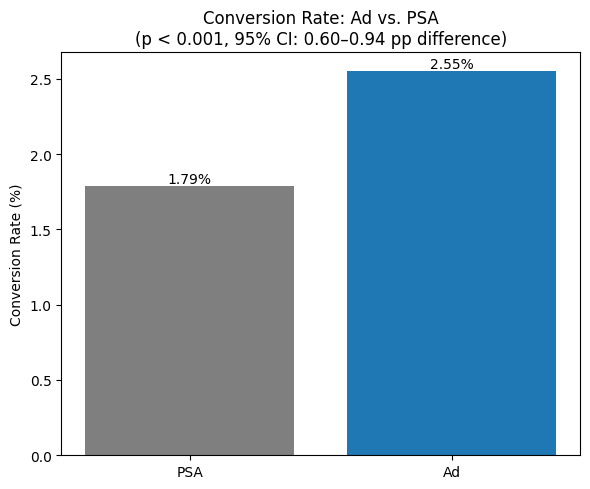

In [8]:
import matplotlib.pyplot as plt

groups = ['PSA', 'Ad']
rates = [conversion_stats.loc['psa', 'conversion_rate_pct'], conversion_stats.loc['ad', 'conversion_rate_pct']]

plt.figure(figsize=(6, 5))
bars = plt.bar(groups, rates, color=['#7f7f7f', '#1f77b4'])
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate: Ad vs. PSA\n(p < 0.001, 95% CI: 0.60–0.94 pp difference)')
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{rate}%', ha='center')
plt.tight_layout()
plt.show()

## Does Ad Exposure Frequency Matter?

Checking whether the two groups differed in how many ads/PSAs they were shown,
to rule out exposure count as a confound in the result above.

In [9]:
print(df.groupby('test group')['total ads'].describe())

               count       mean        std  min  25%   50%   75%     max
test group                                                              
ad          564577.0  24.823365  43.750456  1.0  4.0  13.0  27.0  2065.0
psa          23524.0  24.761138  42.860720  1.0  4.0  12.0  26.0   907.0


Both groups saw nearly identical average exposure (~24.8 ads each), so the
conversion difference above is driven by content type, not frequency.
Separately, checking whether conversion rate rises with exposure *within* the
ad group.

In [10]:
ad_only = df[df['test group'] == 'ad'].copy()
ad_only['ad_bucket'] = pd.cut(ad_only['total ads'], bins=[0, 5, 15, 30, 100, 3000],
                                labels=['1-5', '6-15', '16-30', '31-100', '100+'])
exposure_conversion = ad_only.groupby('ad_bucket', observed=True)['converted'].mean() * 100
print(exposure_conversion)

ad_bucket
1-5        0.251233
6-15       0.605061
16-30      1.395216
31-100     7.357543
100+      17.135214
Name: converted, dtype: float64


Conversion climbs sharply with exposure (0.25% → 17.1%). Important caveat:
this is very likely reverse causation rather than a pure ad effect. Users who
see 100+ ads are users who kept browsing for a long time, and are plausibly
more engaged and more likely to convert regardless of the ads themselves.
Engagement level likely drives both variables — this is a correlation, not
proof that more ads cause more conversions.

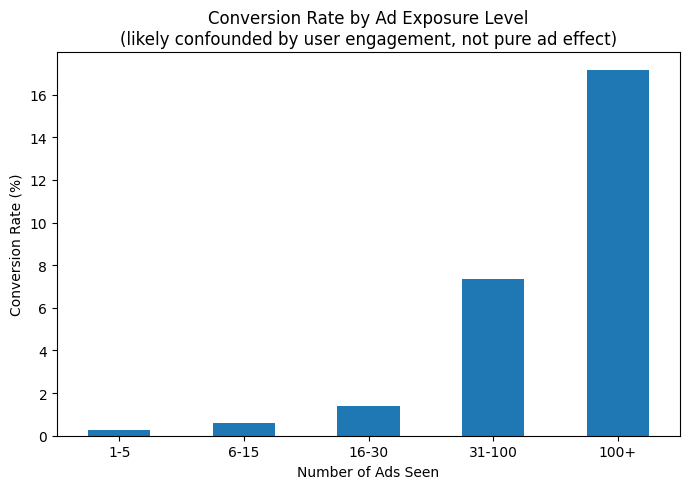

In [11]:
plt.figure(figsize=(7, 5))
exposure_conversion.plot(kind='bar', color='#1f77b4')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Number of Ads Seen')
plt.title('Conversion Rate by Ad Exposure Level\n(likely confounded by user engagement, not pure ad effect)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()